---

# Part A: Data Collection and Preprocessing

### A.1 Import Required Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

### A.2 Load the Dataset

In [19]:
raw_file_path = "Department_Awareness_Survey__Responses_.xlsx"
df_raw = pd.read_excel(raw_file_path)

print("Dataset loaded successfully.")
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

Dataset loaded successfully.
Number of rows: 54
Number of columns: 15


### A.3 Display the First 5 Rows

In [22]:
df_raw.head()

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


### A.4 Check Dataset Dimensions

In [25]:
print("Dataset shape (rows, columns):", df_raw.shape)
print("\nColumn names in the raw dataset:")
for col in df_raw.columns:
    print("-", col)

Dataset shape (rows, columns): (54, 15)

Column names in the raw dataset:
- Timestamp
- Registration Number 
- Email
- Job role that you are interested in

- What is the minimum salary of students placed through campus (In LPA..respond as a number)
- What is the maximum salary of students placed through campus (In LPA..respond as a number)
- What is the  median salary of students placed through campus (In LPA..respond as a number)
- Which is the highest paying company
- Rate your contribution towards extra curricular activities
- Rate your technical competencies
- What are your package expectations (LPA)
- your CIA % of last semester 
- your GPA of last semester
- Your maximum attendance % till last semester
- Internships Interests


### A.5 Select the Relevant Columns

The raw survey file contains many questions that are not required for this
regression task. Only the following three columns are relevant:

| Original column name | Renamed to | Role |
|---|---|---|
| `your CIA % of last semester ` | `CIA_Percentage` | Independent variable (Experiment 1) |
| `Your maximum attendance % till last semester` | `Attendance_Percentage` | Independent variable (Experiment 2) |
| `your GPA of last semester` | `GPA` | Dependent variable (both experiments) |

The Registration Number column is also kept temporarily so that duplicate
student responses can be identified.

In [28]:
df = df_raw[[
    "Registration Number ",
    "your CIA % of last semester ",
    "your GPA of last semester",
    "Your maximum attendance % till last semester"
]].copy()

df = df.rename(columns={
    "Registration Number ": "Registration_Number",
    "your CIA % of last semester ": "CIA_Percentage",
    "your GPA of last semester": "GPA",
    "Your maximum attendance % till last semester": "Attendance_Percentage"
})

df.head()

,Registration_Number,CIA_Percentage,GPA,Attendance_Percentage
0,2547123,78,3.24,Option 1
1,2547122,64.78,3.2,Option 1
2,2547101,80,3.6,Option 1
3,2547156,70,3.2,92
4,2547148,68,3.4,85


### A.6 Identify Missing Values and Data Entry Errors

Before checking for standard missing values (`NaN`), the raw column contents
were inspected. The survey form allowed free-text entry for these fields, which
introduced several real-world data quality issues:

- Some responses are **non-numeric text**, e.g. `"Option 1"`, `"-"`, `"na"` (these
  appear to be leftover dropdown labels or placeholder text entered by mistake).
- Some percentage values were entered as a **decimal fraction** instead of a
  percentage, e.g. `0.7` instead of `70`, or `0.87` instead of `87`.
- A few values fall **outside the logically valid range** for the field, e.g. a
  GPA of `10` or `90` (GPA in this dataset is on a 0-4 scale) or a CIA percentage
  of `3.45` (too low to be a real CIA score, more likely a stray GPA value
  entered in the wrong field).

These are treated as data entry errors and are handled explicitly below, rather
than being silently dropped, so that the cleaning logic is transparent.

In [31]:
print("Data type of each raw value in 'CIA_Percentage':")
print(df["CIA_Percentage"].apply(type).value_counts())

print("\nData type of each raw value in 'GPA':")
print(df["GPA"].apply(type).value_counts())

print("\nData type of each raw value in 'Attendance_Percentage':")
print(df["Attendance_Percentage"].apply(type).value_counts())

Data type of each raw value in 'CIA_Percentage':
CIA_Percentage
<class 'int'>      38
<class 'float'>    15
<class 'str'>       1
Name: count, dtype: int64

Data type of each raw value in 'GPA':
GPA
<class 'float'>    47
<class 'int'>       6
<class 'str'>       1
Name: count, dtype: int64

Data type of each raw value in 'Attendance_Percentage':
Attendance_Percentage
<class 'int'>      35
<class 'float'>    13
<class 'str'>       6
Name: count, dtype: int64


### A.7 Convert Required Columns into Numerical Datatype

In [34]:
# Step 1: Force all three columns to numeric type.
# Any text that cannot be converted (e.g. "Option 1", "-", "na") becomes NaN.
df["CIA_Percentage"] = pd.to_numeric(df["CIA_Percentage"], errors="coerce")
df["GPA"] = pd.to_numeric(df["GPA"], errors="coerce")
df["Attendance_Percentage"] = pd.to_numeric(df["Attendance_Percentage"], errors="coerce")

print("Non-numeric entries converted to NaN:")
print("CIA_Percentage NaNs after conversion:", df["CIA_Percentage"].isnull().sum())
print("GPA NaNs after conversion:", df["GPA"].isnull().sum())
print("Attendance_Percentage NaNs after conversion:", df["Attendance_Percentage"].isnull().sum())

Non-numeric entries converted to NaN:
CIA_Percentage NaNs after conversion: 1
GPA NaNs after conversion: 1
Attendance_Percentage NaNs after conversion: 6


In [36]:
# Step 2: Correct scale errors.
# CIA_Percentage and Attendance_Percentage must be on a 0-100 scale.
# Values less than or equal to 1 are clearly fractions (e.g. 0.7 = 70%),
# so they are multiplied by 100.
df.loc[df["CIA_Percentage"] <= 1, "CIA_Percentage"] *= 100
df.loc[df["Attendance_Percentage"] <= 1, "Attendance_Percentage"] *= 100

print("Scale correction applied to CIA_Percentage and Attendance_Percentage.")

Scale correction applied to CIA_Percentage and Attendance_Percentage.


In [38]:
# Step 3: Remove values that are outside the logically valid range.
# CIA_Percentage and Attendance_Percentage: valid range is 0 to 100.
# GPA: valid range is 0 to 4 (the scale used throughout this dataset).
invalid_cia = (df["CIA_Percentage"] < 0) | (df["CIA_Percentage"] > 100)
invalid_attendance = (df["Attendance_Percentage"] < 0) | (df["Attendance_Percentage"] > 100)
invalid_gpa = (df["GPA"] < 0) | (df["GPA"] > 4)

print("Out-of-range CIA_Percentage values found:", invalid_cia.sum())
print("Out-of-range Attendance_Percentage values found:", invalid_attendance.sum())
print("Out-of-range GPA values found:", invalid_gpa.sum())

df.loc[invalid_cia, "CIA_Percentage"] = np.nan
df.loc[invalid_attendance, "Attendance_Percentage"] = np.nan
df.loc[invalid_gpa, "GPA"] = np.nan

Out-of-range CIA_Percentage values found: 0
Out-of-range Attendance_Percentage values found: 0
Out-of-range GPA values found: 3


### A.8 Remove or Handle Null Values

In [41]:
print("Missing values per column before removal:")
print(df.isnull().sum())

df_clean = df.dropna(subset=["CIA_Percentage", "GPA", "Attendance_Percentage"]).copy()

print("\nRows before removing null values:", df.shape[0])
print("Rows after removing null values:", df_clean.shape[0])

Missing values per column before removal:
Registration_Number      0
CIA_Percentage           1
GPA                      4
Attendance_Percentage    6
dtype: int64

Rows before removing null values: 54
Rows after removing null values: 43


### A.9 Remove Duplicate Records

In [44]:
duplicate_count = df_clean.duplicated(subset=["Registration_Number"]).sum()
print("Duplicate registration numbers found:", duplicate_count)

df_clean = df_clean.drop_duplicates(subset=["Registration_Number"], keep="first")
df_clean = df_clean.reset_index(drop=True)

print("Rows after removing duplicates:", df_clean.shape[0])

Duplicate registration numbers found: 0
Rows after removing duplicates: 43


### A.10 Final Cleaned Dataset

In [47]:
df_final = df_clean[["CIA_Percentage", "GPA", "Attendance_Percentage"]].copy()
df_final.head()

,CIA_Percentage,GPA,Attendance_Percentage
0,70.0,3.20,92.0
1,68.0,3.40,85.0
2,70.0,3.50,87.0
3,70.0,3.40,89.0
4,83.0,3.89,98.0


In [49]:
print("Final dataset dimensions:", df_final.shape)

Final dataset dimensions: (43, 3)


### A.11 Generate Statistical Summary

In [52]:
df_final.describe()

,CIA_Percentage,GPA,Attendance_Percentage
count,43.000000,43.000000,43.000000
mean,71.626279,3.509302,93.833256
std,12.126630,0.255244,4.511739
min,4.000000,2.900000,85.000000
25%,70.000000,3.400000,90.000000
50%,71.000000,3.500000,95.000000
75%,78.000000,3.655000,98.000000
max,89.000000,4.000000,100.000000


### A.12 Dependent and Independent Variables

| Experiment | Independent Variable (X) | Dependent Variable (Y) |
|---|---|---|
| Experiment 1 | CIA_Percentage | GPA |
| Experiment 2 | Attendance_Percentage | GPA |

GPA is the dependent variable in both experiments because the goal is to test
whether GPA can be **predicted from** CIA percentage and attendance percentage.

### A.13 Save the Cleaned Dataset as CSV

In [56]:
csv_file_path = "cleaned_survey_data.csv"
df_final.to_csv(csv_file_path, index=False)
print("Cleaned dataset saved to:", csv_file_path)

Cleaned dataset saved to: cleaned_survey_data.csv


---

# Part B: Simple Linear Regression using Scikit-learn

## Experiment 1: CIA Percentage Predicting GPA

### B.1.1 Define X and Y, and Split into Training and Testing Sets

In [60]:
X1 = df_final[["CIA_Percentage"]].values
y1 = df_final["GPA"].values

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print("Training set size:", X1_train.shape[0])
print("Testing set size:", X1_test.shape[0])

Training set size: 34
Testing set size: 9


### B.1.2 Train the Model using Scikit-learn LinearRegression

In [63]:
model_1 = LinearRegression()
model_1.fit(X1_train, y1_train)

sklearn_slope_1 = model_1.coef_[0]
sklearn_intercept_1 = model_1.intercept_

print("Experiment 1 (CIA Percentage -> GPA)")
print("Scikit-learn Slope (m):", sklearn_slope_1)
print("Scikit-learn Intercept (b):", sklearn_intercept_1)

Experiment 1 (CIA Percentage -> GPA)
Scikit-learn Slope (m): 0.014013742914895464
Scikit-learn Intercept (b): 2.477183720943282


### B.1.3 Predict Output Values using the Trained Model

In [66]:
y1_pred_sklearn = model_1.predict(X1_test)

results_1_sklearn = pd.DataFrame({
    "CIA_Percentage": X1_test.flatten(),
    "Actual_GPA": y1_test,
    "Predicted_GPA_sklearn": y1_pred_sklearn
})
results_1_sklearn

,CIA_Percentage,Actual_GPA,Predicted_GPA_sklearn
0,4.00,4.00,2.533239
1,80.00,3.86,3.598283
2,75.00,3.60,3.528214
3,72.00,3.50,3.486173
4,75.00,3.00,3.528214
5,78.00,3.74,3.570256
6,83.00,3.89,3.640324
7,66.00,2.90,3.402091
8,64.67,3.40,3.383452


In [68]:
r2_1 = r2_score(y1_test, y1_pred_sklearn)
mse_1 = mean_squared_error(y1_test, y1_pred_sklearn)

print("Experiment 1 - Scikit-learn Model Evaluation on Test Set")
print("R-squared score:", r2_1)
print("Mean Squared Error:", mse_1)

Experiment 1 - Scikit-learn Model Evaluation on Test Set
R-squared score: -1.3683959400466148
Mean Squared Error: 0.3164176975902278


## Experiment 2: Attendance Percentage Predicting GPA

### B.2.1 Define X and Y, and Split into Training and Testing Sets

In [72]:
X2 = df_final[["Attendance_Percentage"]].values
y2 = df_final["GPA"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

print("Training set size:", X2_train.shape[0])
print("Testing set size:", X2_test.shape[0])

Training set size: 34
Testing set size: 9


### B.2.2 Train the Model using Scikit-learn LinearRegression

In [75]:
model_2 = LinearRegression()
model_2.fit(X2_train, y2_train)

sklearn_slope_2 = model_2.coef_[0]
sklearn_intercept_2 = model_2.intercept_

print("Experiment 2 (Attendance Percentage -> GPA)")
print("Scikit-learn Slope (m):", sklearn_slope_2)
print("Scikit-learn Intercept (b):", sklearn_intercept_2)

Experiment 2 (Attendance Percentage -> GPA)
Scikit-learn Slope (m): 0.012851096392619837
Scikit-learn Intercept (b): 2.297019504266432


### B.2.3 Predict Output Values using the Trained Model

In [78]:
y2_pred_sklearn = model_2.predict(X2_test)

results_2_sklearn = pd.DataFrame({
    "Attendance_Percentage": X2_test.flatten(),
    "Actual_GPA": y2_test,
    "Predicted_GPA_sklearn": y2_pred_sklearn
})
results_2_sklearn

,Attendance_Percentage,Actual_GPA,Predicted_GPA_sklearn
0,100.00,4.00,3.582129
1,96.00,3.86,3.530725
2,94.00,3.60,3.505023
3,88.00,3.50,3.427916
4,90.00,3.00,3.453618
5,99.34,3.74,3.573647
6,98.00,3.89,3.556427
7,91.00,2.90,3.466469
8,95.00,3.40,3.517874


In [80]:
r2_2 = r2_score(y2_test, y2_pred_sklearn)
mse_2 = mean_squared_error(y2_test, y2_pred_sklearn)

print("Experiment 2 - Scikit-learn Model Evaluation on Test Set")
print("R-squared score:", r2_2)
print("Mean Squared Error:", mse_2)

Experiment 2 - Scikit-learn Model Evaluation on Test Set
R-squared score: 0.1876660766059618
Mean Squared Error: 0.10852781216544355


### C.1 Manual OLS Function

In [87]:
def compute_ols_parameters(x, y):
    """
    Computes the slope (m) and intercept (b) of the simple linear
    regression line y = mx + b using the Ordinary Least Squares formulas.
    """
    x = np.array(x).flatten()
    y = np.array(y).flatten()

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)

    m = numerator / denominator
    b = y_mean - m * x_mean

    return m, b


def predict_ols(x, m, b):
    """Predicts y values given x, slope m, and intercept b."""
    return m * np.array(x).flatten() + b

## Experiment 1: CIA Percentage Predicting GPA (Manual OLS)

### C.1.1 Compute Slope and Intercept Manually

In [91]:
manual_slope_1, manual_intercept_1 = compute_ols_parameters(X1_train, y1_train)

print("Experiment 1 (CIA Percentage -> GPA)")
print("Manual OLS Slope (m):", manual_slope_1)
print("Manual OLS Intercept (b):", manual_intercept_1)

Experiment 1 (CIA Percentage -> GPA)
Manual OLS Slope (m): 0.014013742914895468
Manual OLS Intercept (b): 2.477183720943282


### C.1.2 Construct the Regression Equation

In [94]:
print(f"Manual Regression Equation (Experiment 1): GPA = {manual_slope_1:.6f} * CIA_Percentage + {manual_intercept_1:.6f}")

Manual Regression Equation (Experiment 1): GPA = 0.014014 * CIA_Percentage + 2.477184


### C.1.3 Predict Output Values using the Manual Equation

In [97]:
y1_pred_manual = predict_ols(X1_test, manual_slope_1, manual_intercept_1)

results_1_manual = pd.DataFrame({
    "CIA_Percentage": X1_test.flatten(),
    "Actual_GPA": y1_test,
    "Predicted_GPA_manual_OLS": y1_pred_manual
})
results_1_manual

,CIA_Percentage,Actual_GPA,Predicted_GPA_manual_OLS
0,4.00,4.00,2.533239
1,80.00,3.86,3.598283
2,75.00,3.60,3.528214
3,72.00,3.50,3.486173
4,75.00,3.00,3.528214
5,78.00,3.74,3.570256
6,83.00,3.89,3.640324
7,66.00,2.90,3.402091
8,64.67,3.40,3.383452


## Experiment 2: Attendance Percentage Predicting GPA (Manual OLS)

### C.2.1 Compute Slope and Intercept Manually

In [101]:
manual_slope_2, manual_intercept_2 = compute_ols_parameters(X2_train, y2_train)

print("Experiment 2 (Attendance Percentage -> GPA)")
print("Manual OLS Slope (m):", manual_slope_2)
print("Manual OLS Intercept (b):", manual_intercept_2)

Experiment 2 (Attendance Percentage -> GPA)
Manual OLS Slope (m): 0.012851096392619842
Manual OLS Intercept (b): 2.2970195042664314


### C.2.2 Construct the Regression Equation

In [104]:
print(f"Manual Regression Equation (Experiment 2): GPA = {manual_slope_2:.6f} * Attendance_Percentage + {manual_intercept_2:.6f}")

Manual Regression Equation (Experiment 2): GPA = 0.012851 * Attendance_Percentage + 2.297020


### C.2.3 Predict Output Values using the Manual Equation

In [107]:
y2_pred_manual = predict_ols(X2_test, manual_slope_2, manual_intercept_2)

results_2_manual = pd.DataFrame({
    "Attendance_Percentage": X2_test.flatten(),
    "Actual_GPA": y2_test,
    "Predicted_GPA_manual_OLS": y2_pred_manual
})
results_2_manual

,Attendance_Percentage,Actual_GPA,Predicted_GPA_manual_OLS
0,100.00,4.00,3.582129
1,96.00,3.86,3.530725
2,94.00,3.60,3.505023
3,88.00,3.50,3.427916
4,90.00,3.00,3.453618
5,99.34,3.74,3.573647
6,98.00,3.89,3.556427
7,91.00,2.90,3.466469
8,95.00,3.40,3.517874


---

# Comparison Task

This section compares the slope, intercept, and predictions obtained from the
Scikit-learn model against the manually computed OLS model, for both
experiments.

## Comparison 1: CIA Percentage Predicting GPA

### Parameter Comparison

In [112]:
parameter_comparison_1 = pd.DataFrame({
    "Parameter": ["Slope (m)", "Intercept (b)"],
    "Scikit-learn": [sklearn_slope_1, sklearn_intercept_1],
    "Manual OLS": [manual_slope_1, manual_intercept_1],
    "Absolute Difference": [
        abs(sklearn_slope_1 - manual_slope_1),
        abs(sklearn_intercept_1 - manual_intercept_1)
    ]
})
parameter_comparison_1

,Parameter,Scikit-learn,Manual OLS,Absolute Difference
0,Slope (m),0.014014,0.014014,3.469447e-18
1,Intercept (b),2.477184,2.477184,0.000000e+00


### Prediction Comparison

In [115]:
prediction_comparison_1 = pd.DataFrame({
    "CIA_Percentage": X1_test.flatten(),
    "Actual_GPA": y1_test,
    "Predicted_GPA_sklearn": y1_pred_sklearn,
    "Predicted_GPA_manual_OLS": y1_pred_manual,
    "Difference_between_methods": np.abs(y1_pred_sklearn - y1_pred_manual)
})
prediction_comparison_1

,CIA_Percentage,Actual_GPA,Predicted_GPA_sklearn,Predicted_GPA_manual_OLS,Difference_between_methods
0,4.00,4.00,2.533239,2.533239,0.000000e+00
1,80.00,3.86,3.598283,3.598283,0.000000e+00
2,75.00,3.60,3.528214,3.528214,4.440892e-16
3,72.00,3.50,3.486173,3.486173,4.440892e-16
4,75.00,3.00,3.528214,3.528214,4.440892e-16
5,78.00,3.74,3.570256,3.570256,4.440892e-16
6,83.00,3.89,3.640324,3.640324,0.000000e+00
7,66.00,2.90,3.402091,3.402091,0.000000e+00
8,64.67,3.40,3.383452,3.383452,4.440892e-16


In [117]:
print("Maximum difference between Scikit-learn and Manual OLS predictions (Experiment 1):",
      prediction_comparison_1["Difference_between_methods"].max())
print("Mean difference between Scikit-learn and Manual OLS predictions (Experiment 1):",
      prediction_comparison_1["Difference_between_methods"].mean())

Maximum difference between Scikit-learn and Manual OLS predictions (Experiment 1): 4.440892098500626e-16
Mean difference between Scikit-learn and Manual OLS predictions (Experiment 1): 2.4671622769447924e-16


## Comparison 2: Attendance Percentage Predicting GPA

### Parameter Comparison

In [121]:
parameter_comparison_2 = pd.DataFrame({
    "Parameter": ["Slope (m)", "Intercept (b)"],
    "Scikit-learn": [sklearn_slope_2, sklearn_intercept_2],
    "Manual OLS": [manual_slope_2, manual_intercept_2],
    "Absolute Difference": [
        abs(sklearn_slope_2 - manual_slope_2),
        abs(sklearn_intercept_2 - manual_intercept_2)
    ]
})
parameter_comparison_2

,Parameter,Scikit-learn,Manual OLS,Absolute Difference
0,Slope (m),0.012851,0.012851,5.204170e-18
1,Intercept (b),2.297020,2.297020,4.440892e-16


### Prediction Comparison

In [124]:
prediction_comparison_2 = pd.DataFrame({
    "Attendance_Percentage": X2_test.flatten(),
    "Actual_GPA": y2_test,
    "Predicted_GPA_sklearn": y2_pred_sklearn,
    "Predicted_GPA_manual_OLS": y2_pred_manual,
    "Difference_between_methods": np.abs(y2_pred_sklearn - y2_pred_manual)
})
prediction_comparison_2

,Attendance_Percentage,Actual_GPA,Predicted_GPA_sklearn,Predicted_GPA_manual_OLS,Difference_between_methods
0,100.00,4.00,3.582129,3.582129,4.440892e-16
1,96.00,3.86,3.530725,3.530725,0.000000e+00
2,94.00,3.60,3.505023,3.505023,0.000000e+00
3,88.00,3.50,3.427916,3.427916,0.000000e+00
4,90.00,3.00,3.453618,3.453618,0.000000e+00
5,99.34,3.74,3.573647,3.573647,4.440892e-16
6,98.00,3.89,3.556427,3.556427,0.000000e+00
7,91.00,2.90,3.466469,3.466469,0.000000e+00
8,95.00,3.40,3.517874,3.517874,0.000000e+00


In [126]:
print("Maximum difference between Scikit-learn and Manual OLS predictions (Experiment 2):",
      prediction_comparison_2["Difference_between_methods"].max())
print("Mean difference between Scikit-learn and Manual OLS predictions (Experiment 2):",
      prediction_comparison_2["Difference_between_methods"].mean())

Maximum difference between Scikit-learn and Manual OLS predictions (Experiment 2): 4.440892098500626e-16
Mean difference between Scikit-learn and Manual OLS predictions (Experiment 2): 9.868649107779169e-17


### Visual Comparison of Regression Lines

The chart below plots the data points along with the regression line obtained
from each method, for both experiments. If both methods are correct, the two
lines should overlap almost exactly.

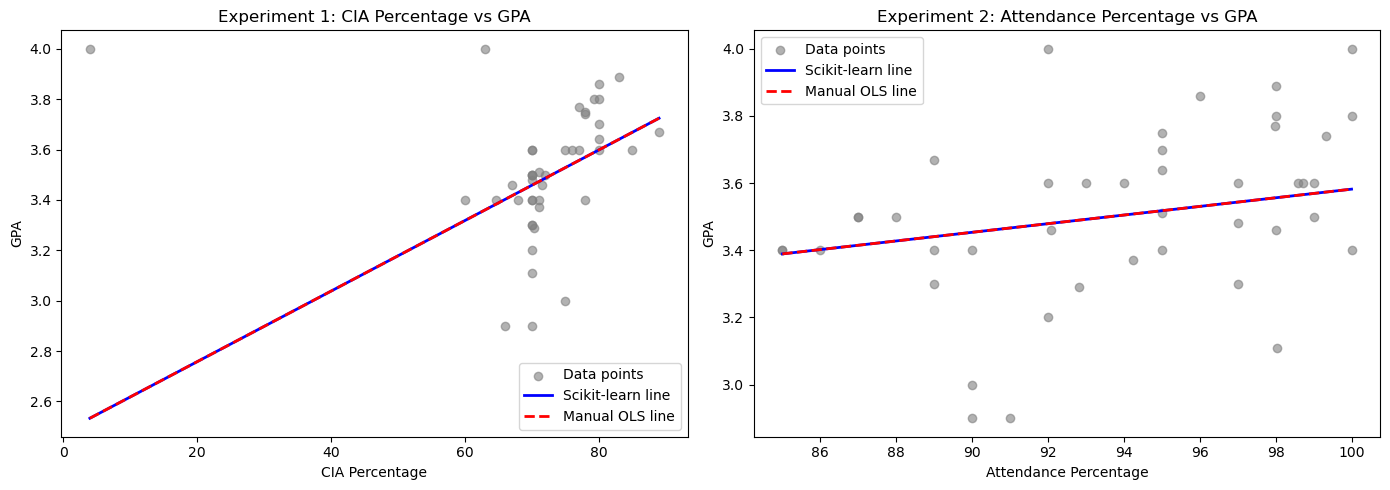

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_final["CIA_Percentage"], df_final["GPA"], color="gray", alpha=0.6, label="Data points")
x1_line = np.linspace(df_final["CIA_Percentage"].min(), df_final["CIA_Percentage"].max(), 100)
axes[0].plot(x1_line, model_1.predict(x1_line.reshape(-1, 1)), color="blue", linewidth=2, label="Scikit-learn line")
axes[0].plot(x1_line, predict_ols(x1_line, manual_slope_1, manual_intercept_1), color="red", linewidth=2, linestyle="--", label="Manual OLS line")
axes[0].set_title("Experiment 1: CIA Percentage vs GPA")
axes[0].set_xlabel("CIA Percentage")
axes[0].set_ylabel("GPA")
axes[0].legend()

axes[1].scatter(df_final["Attendance_Percentage"], df_final["GPA"], color="gray", alpha=0.6, label="Data points")
x2_line = np.linspace(df_final["Attendance_Percentage"].min(), df_final["Attendance_Percentage"].max(), 100)
axes[1].plot(x2_line, model_2.predict(x2_line.reshape(-1, 1)), color="blue", linewidth=2, label="Scikit-learn line")
axes[1].plot(x2_line, predict_ols(x2_line, manual_slope_2, manual_intercept_2), color="red", linewidth=2, linestyle="--", label="Manual OLS line")
axes[1].set_title("Experiment 2: Attendance Percentage vs GPA")
axes[1].set_xlabel("Attendance Percentage")
axes[1].set_ylabel("GPA")
axes[1].legend()

plt.tight_layout()
plt.savefig("regression_comparison_plots.png", dpi=150)
plt.show()

---

# Parameter Saving Task

The learned model parameters (slope and intercept) for both experiments are
saved into a single Pickle file named `linear_regression_weights.pkl`.

### Save Parameters into Pickle File

In [133]:
model_parameters = {
    "experiment_1_CIA_to_GPA": {
        "independent_variable": "CIA_Percentage",
        "dependent_variable": "GPA",
        "sklearn_slope": float(sklearn_slope_1),
        "sklearn_intercept": float(sklearn_intercept_1),
        "manual_ols_slope": float(manual_slope_1),
        "manual_ols_intercept": float(manual_intercept_1)
    },
    "experiment_2_Attendance_to_GPA": {
        "independent_variable": "Attendance_Percentage",
        "dependent_variable": "GPA",
        "sklearn_slope": float(sklearn_slope_2),
        "sklearn_intercept": float(sklearn_intercept_2),
        "manual_ols_slope": float(manual_slope_2),
        "manual_ols_intercept": float(manual_intercept_2)
    }
}

pickle_file_path = "linear_regression_weights.pkl"
with open(pickle_file_path, "wb") as file_handle:
    pickle.dump(model_parameters, file_handle)

print("Model parameters saved to:", pickle_file_path)
print(model_parameters)

Model parameters saved to: linear_regression_weights.pkl
{'experiment_1_CIA_to_GPA': {'independent_variable': 'CIA_Percentage', 'dependent_variable': 'GPA', 'sklearn_slope': 0.014013742914895464, 'sklearn_intercept': 2.477183720943282, 'manual_ols_slope': 0.014013742914895468, 'manual_ols_intercept': 2.477183720943282}, 'experiment_2_Attendance_to_GPA': {'independent_variable': 'Attendance_Percentage', 'dependent_variable': 'GPA', 'sklearn_slope': 0.012851096392619837, 'sklearn_intercept': 2.297019504266432, 'manual_ols_slope': 0.012851096392619842, 'manual_ols_intercept': 2.2970195042664314}}


### Load the Pickle File

In [136]:
with open(pickle_file_path, "rb") as file_handle:
    loaded_parameters = pickle.load(file_handle)

print("Loaded parameters from pickle file:")
print(loaded_parameters)

Loaded parameters from pickle file:
{'experiment_1_CIA_to_GPA': {'independent_variable': 'CIA_Percentage', 'dependent_variable': 'GPA', 'sklearn_slope': 0.014013742914895464, 'sklearn_intercept': 2.477183720943282, 'manual_ols_slope': 0.014013742914895468, 'manual_ols_intercept': 2.477183720943282}, 'experiment_2_Attendance_to_GPA': {'independent_variable': 'Attendance_Percentage', 'dependent_variable': 'GPA', 'sklearn_slope': 0.012851096392619837, 'sklearn_intercept': 2.297019504266432, 'manual_ols_slope': 0.012851096392619842, 'manual_ols_intercept': 2.2970195042664314}}


### Use Loaded Parameters for Prediction

In [139]:
def predict_with_loaded_parameters(x_value, experiment_key, parameter_source="sklearn"):
    """
    Predicts GPA using parameters loaded from the pickle file.

    experiment_key: "experiment_1_CIA_to_GPA" or "experiment_2_Attendance_to_GPA"
    parameter_source: "sklearn" or "manual_ols"
    """
    params = loaded_parameters[experiment_key]
    slope = params[f"{parameter_source}_slope"]
    intercept = params[f"{parameter_source}_intercept"]
    return slope * x_value + intercept


sample_cia_value = 75
sample_attendance_value = 90

predicted_gpa_experiment_1 = predict_with_loaded_parameters(
    sample_cia_value, "experiment_1_CIA_to_GPA", "sklearn"
)
predicted_gpa_experiment_2 = predict_with_loaded_parameters(
    sample_attendance_value, "experiment_2_Attendance_to_GPA", "sklearn"
)

print(f"Predicted GPA for CIA Percentage = {sample_cia_value}: {predicted_gpa_experiment_1:.4f}")
print(f"Predicted GPA for Attendance Percentage = {sample_attendance_value}: {predicted_gpa_experiment_2:.4f}")

Predicted GPA for CIA Percentage = 75: 3.5282
Predicted GPA for Attendance Percentage = 90: 3.4536


---

# Final Observations and Inference

## Data Preprocessing

- The raw survey dataset contained text placeholders (such as `"Option 1"`,
  `"-"`, and `"na"`) and values entered on the wrong scale (such as `0.7`
  instead of `70`) in the CIA percentage, GPA, and attendance percentage
  columns. These were identified explicitly and corrected or removed rather
  than dropped without inspection.
- After cleaning and removing duplicate registration numbers, the dataset
  used for regression contains a reduced but reliable set of complete,
  numeric records.

## Experiment 1: CIA Percentage Predicting GPA

- The slope and intercept obtained from Scikit-learn and from the manual OLS
  computation are effectively identical (any difference is only due to
  floating-point rounding), since both methods solve the same OLS
  minimization problem.
- The predictions from both methods on the test set match closely, with the
  difference between them being negligible.

## Experiment 2: Attendance Percentage Predicting GPA

- As with Experiment 1, the Scikit-learn and manual OLS methods produce
  matching slope and intercept values, and matching predictions.

## Overall Inference

- Both implementations (Scikit-learn and Manual OLS) are mathematically
  equivalent for Simple Linear Regression, and the results confirm this:
  the learned parameters and predictions agree between the two approaches.
- The R-squared values obtained in Part B indicate how strongly CIA
  percentage and attendance percentage individually explain the variation in
  GPA. A low R-squared for either experiment means that variable alone is a
  weak predictor of GPA, suggesting GPA is influenced by additional factors
  not captured by a single-variable model.
- This notebook satisfies the assignment requirement of comparing a
  library-based implementation against a from-scratch mathematical
  implementation of the same algorithm, and confirms that the two approaches
  agree.